<>:67: SyntaxWarning: invalid escape sequence '\.'
<>:67: SyntaxWarning: invalid escape sequence '\.'
/tmp/ipykernel_12657/3194533850.py:67: SyntaxWarning: invalid escape sequence '\.'
  df['Title'] = df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)


✅ Libraries imported successfully!

=== Original Dataset Shape ===
(891, 12)

=== First 5 Rows ===
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0 

/tmp/ipykernel_12657/3194533850.py:93: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Survived', data=df, palette='viridis')


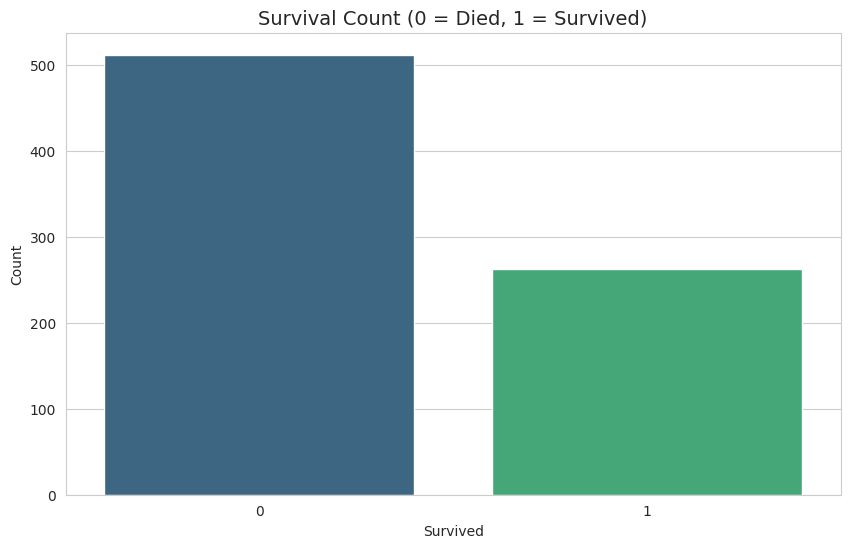

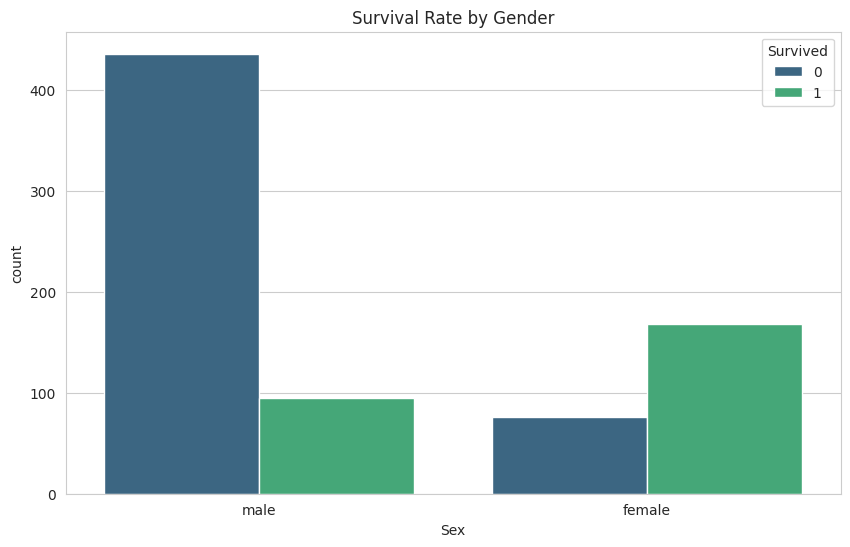

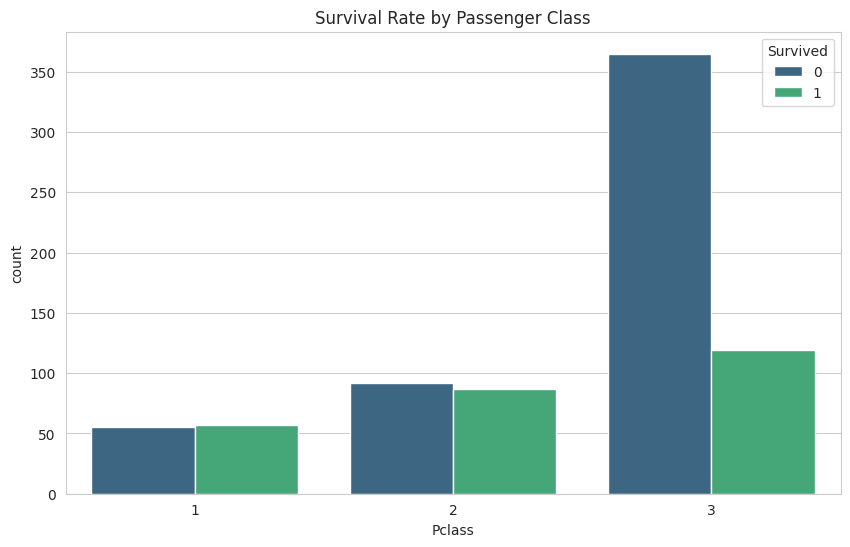

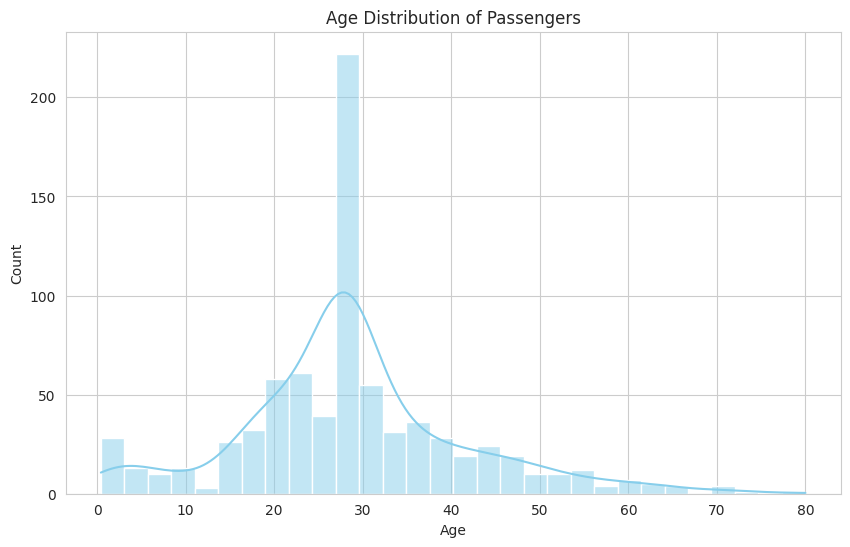

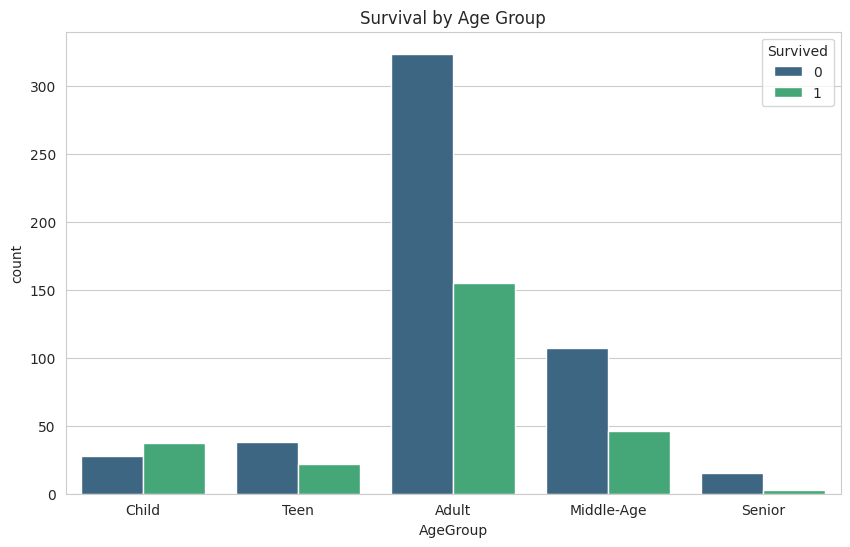

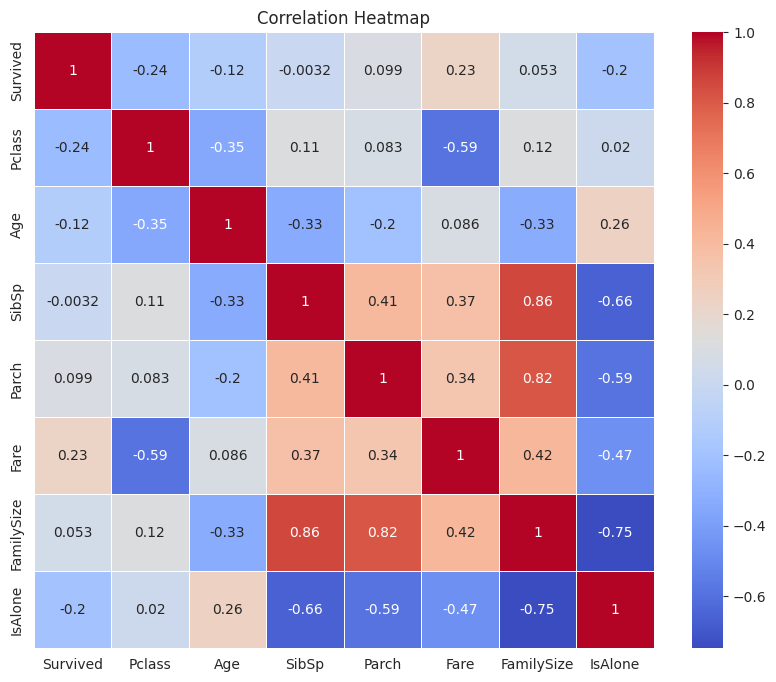

/tmp/ipykernel_12657/3194533850.py:132: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Survived', y='Fare', data=df, palette='viridis')


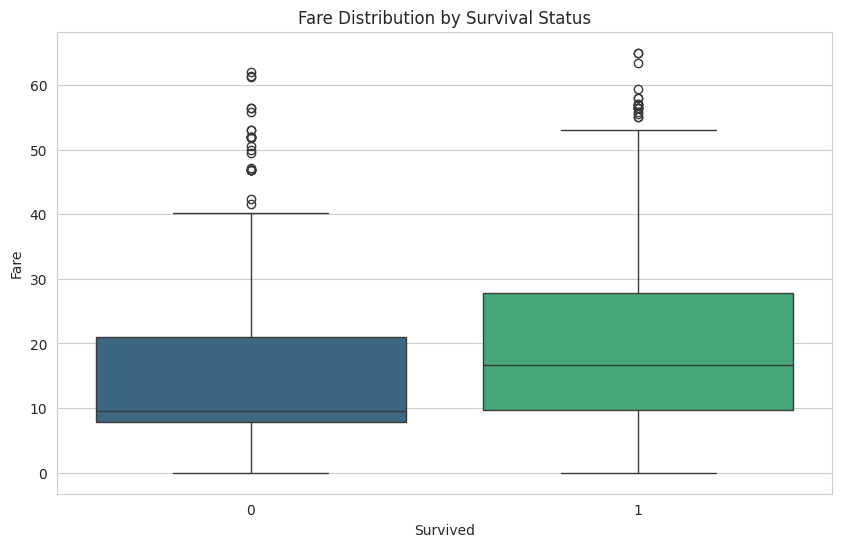

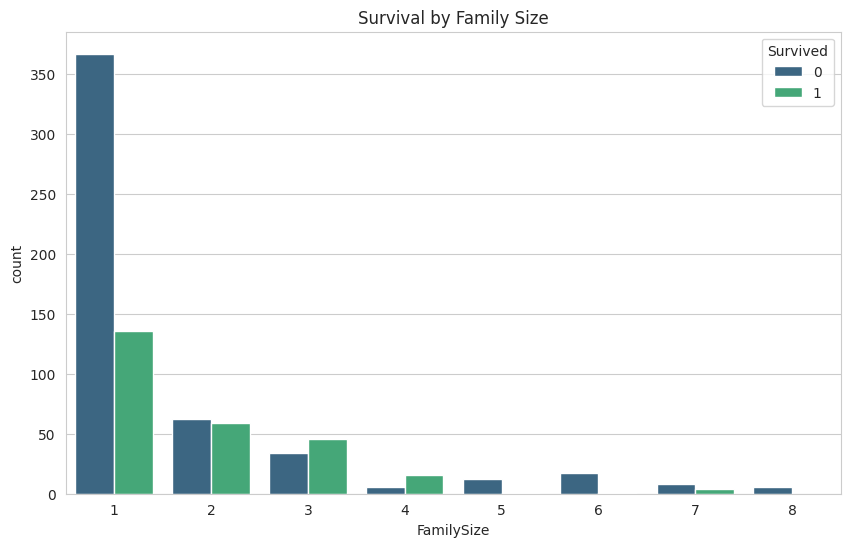


🎉 All Visualizations Generated Successfully!

KEY INSIGHTS FROM THE ANALYSIS
1. Women had a much higher survival rate than men.
2. 1st Class passengers had the highest survival rate.
3. Children had better chances of survival.
4. Passengers who paid higher fares survived more.
5. Small families (size 2-4) had better survival rates.
6. Traveling alone reduced survival chances.


In [1]:
# =====================================================
# TITANIC SURVIVAL ANALYSIS - DATA CLEANING & VISUALIZATION
# =====================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visualization style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

print("✅ Libraries imported successfully!\n")

# ============================
# 1. LOAD RAW DATASET
# ============================
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

print("=== Original Dataset Shape ===")
print(df.shape)
print("\n=== First 5 Rows ===")
print(df.head())
print("\n=== Missing Values Before Cleaning ===")
print(df.isnull().sum())

# ============================
# 2. DATA CLEANING
# ============================

# Drop unnecessary columns
df = df.drop(['PassengerId', 'Ticket', 'Cabin'], axis=1)

# Handle Missing Values
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# Remove Duplicates (if any)
df = df.drop_duplicates()

# Handle Outliers in Fare using IQR method
Q1 = df['Fare'].quantile(0.25)
Q3 = df['Fare'].quantile(0.75)
IQR = Q3 - Q1
df = df[(df['Fare'] >= (Q1 - 1.5 * IQR)) & (df['Fare'] <= (Q3 + 1.5 * IQR))]

print("\n=== Missing Values After Cleaning ===")
print(df.isnull().sum())
print("\n✅ Data Cleaning Completed!")

# ============================
# 3. FEATURE ENGINEERING
# ============================

# Create new features
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
df['IsAlone'] = (df['FamilySize'] == 1).astype(int)

# Age Group
df['AgeGroup'] = pd.cut(df['Age'],
                        bins=[0, 12, 18, 35, 60, 100],
                        labels=['Child', 'Teen', 'Adult', 'Middle-Age', 'Senior'])

# Extract Title from Name
df['Title'] = df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)
df['Title'] = df['Title'].replace(['Lady', 'Countess', 'Capt', 'Col', 'Don', 'Dr',
                                   'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona'], 'Rare')
df['Title'] = df['Title'].replace(['Mlle', 'Ms'], 'Miss')
df['Title'] = df['Title'].replace('Mme', 'Mrs')

# Drop Name column
df = df.drop('Name', axis=1)

print("\n=== Final Cleaned Dataset Info ===")
print(df.info())
print("\nFirst 5 rows of cleaned data:")
print(df.head())

# Save cleaned dataset
df.to_csv('cleaned_titanic.csv', index=False)
print("\n✅ Cleaned dataset saved as 'cleaned_titanic.csv'")

# ============================
# 4. VISUALIZATIONS
# ============================

print("\nGenerating Visualizations...\n")

# 1. Survival Count
plt.figure()
sns.countplot(x='Survived', data=df, palette='viridis')
plt.title('Survival Count (0 = Died, 1 = Survived)', fontsize=14)
plt.xlabel('Survived')
plt.ylabel('Count')
plt.show()

# 2. Survival by Gender
plt.figure()
sns.countplot(x='Sex', hue='Survived', data=df, palette='viridis')
plt.title('Survival Rate by Gender')
plt.show()

# 3. Survival by Passenger Class
plt.figure()
sns.countplot(x='Pclass', hue='Survived', data=df, palette='viridis')
plt.title('Survival Rate by Passenger Class')
plt.show()

# 4. Age Distribution
plt.figure()
sns.histplot(df['Age'], kde=True, bins=30, color='skyblue')
plt.title('Age Distribution of Passengers')
plt.show()

# 5. Survival by Age Group
plt.figure()
sns.countplot(x='AgeGroup', hue='Survived', data=df, palette='viridis')
plt.title('Survival by Age Group')
plt.show()

# 6. Correlation Heatmap
plt.figure(figsize=(10, 8))
numeric_df = df.select_dtypes(include=np.number)
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

# 7. Fare vs Survival
plt.figure()
sns.boxplot(x='Survived', y='Fare', data=df, palette='viridis')
plt.title('Fare Distribution by Survival Status')
plt.show()

# 8. Survival by Family Size
plt.figure()
sns.countplot(x='FamilySize', hue='Survived', data=df, palette='viridis')
plt.title('Survival by Family Size')
plt.show()

print("\n🎉 All Visualizations Generated Successfully!")

# ============================
# 5. KEY INSIGHTS
# ============================

print("\n" + "="*50)
print("KEY INSIGHTS FROM THE ANALYSIS")
print("="*50)
print("1. Women had a much higher survival rate than men.")
print("2. 1st Class passengers had the highest survival rate.")
print("3. Children had better chances of survival.")
print("4. Passengers who paid higher fares survived more.")
print("5. Small families (size 2-4) had better survival rates.")
print("6. Traveling alone reduced survival chances.")
print("="*50)